In [1]:
import pandas as pd

In [2]:
f = '../data/raw/enigh2024_ns_gastoshogar_csv/gastoshogar.csv'
GASTOHOGAR = pd.read_csv(f, 
                       usecols = ['folioviv',
                                  'foliohog',
                                  'clave',
                                  'gasto_tri','num_meses','gasto',
                                  'ultim_pago',
                                  'entidad',
                                  'factor'
                                 ]
                      )
GASTOHOGAR

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor
0,100001901,1,011131,13,,,167.14,1,207
1,100001901,1,011150,50,,,642.85,1,207
2,100001901,1,011231,15,,,192.85,1,207
3,100001901,1,011411,38,,,488.57,1,207
4,100001901,1,011460,114,,,1465.71,1,207
...,...,...,...,...,...,...,...,...,...
5311492,3260593818,1,131208,100,,,300,32,183
5311493,3260593818,1,13120A,70,,,210,32,183
5311494,3260593818,1,13120L,120,,,360,32,183
5311495,3260593818,1,181126,15,,,192.85,32,183


In [3]:
GASTOHOGAR_luz = GASTOHOGAR[GASTOHOGAR['clave'] == '045100'].copy()
GASTOHOGAR_luz['gasto_tri'] = pd.to_numeric(GASTOHOGAR_luz['gasto_tri'], errors='coerce')
GASTOHOGAR_luz['num_meses'] = pd.to_numeric(GASTOHOGAR_luz['num_meses'], errors='coerce')
GASTOHOGAR_luz['gasto'] = pd.to_numeric(GASTOHOGAR_luz['gasto'], errors='coerce')
GASTOHOGAR_luz
# GASTOHOGAR_luz = GASTOHOGAR_luz.drop(columns = ['foliohog','clave'])

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor
13,100001901,1,045100,130.0,2.0,2410,195.0,1,207
53,100001902,1,045100,600.0,2.0,2410,900.0,1,207
99,100001904,1,045100,442.0,2.0,2410,663.0,1,207
167,100001905,1,045100,183.0,2.0,2410,274.5,1,207
274,100002501,1,045100,321.0,2.0,2408,481.5,1,196
...,...,...,...,...,...,...,...,...,...
5311270,3260593814,1,045100,120.0,2.0,2408,180.0,32,183
5311341,3260593815,1,045100,300.0,2.0,2408,450.0,32,183
5311397,3260593816,1,045100,280.0,2.0,2408,420.0,32,183
5311436,3260593817,1,045100,120.0,2.0,2408,180.0,32,183


In [4]:
GASTOHOGAR_luz.dtypes

folioviv        int64
foliohog        int64
clave          object
gasto         float64
num_meses     float64
ultim_pago     object
gasto_tri     float64
entidad         int64
factor          int64
dtype: object

In [5]:
GASTOHOGAR_luz

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor
13,100001901,1,045100,130.0,2.0,2410,195.0,1,207
53,100001902,1,045100,600.0,2.0,2410,900.0,1,207
99,100001904,1,045100,442.0,2.0,2410,663.0,1,207
167,100001905,1,045100,183.0,2.0,2410,274.5,1,207
274,100002501,1,045100,321.0,2.0,2408,481.5,1,196
...,...,...,...,...,...,...,...,...,...
5311270,3260593814,1,045100,120.0,2.0,2408,180.0,32,183
5311341,3260593815,1,045100,300.0,2.0,2408,450.0,32,183
5311397,3260593816,1,045100,280.0,2.0,2408,420.0,32,183
5311436,3260593817,1,045100,120.0,2.0,2408,180.0,32,183


In [6]:
GASTOHOGAR_luz['num_meses'].value_counts()

num_meses
2.0     77001
1.0      3567
6.0       390
12.0      190
4.0       174
3.0        60
5.0        35
8.0        22
9.0        20
7.0        19
10.0       18
21.0        8
22.0        8
25.0        5
24.0        5
20.0        4
32.0        3
23.0        2
36.0        1
29.0        1
16.0        1
13.0        1
62.0        1
68.0        1
26.0        1
80.0        1
52.0        1
Name: count, dtype: int64

In [7]:
# La CFE solo reconoce formalemnte 2 periodos de facturacion para contratos domesticos, el mensual y el bimestral https://app.cfe.mx/Aplicaciones/CCFE/Tarifas/TarifasCRECasa/Tarifas/DEPDomesticas.aspx?utm_source=chatgpt.com
# ademas, en la ENIGH se pregunta a cuantos meses corresponde el pago, el hecho de que sean mas de 2, sugiere que se trata de pagos con deudas 
# por atraso de pago, reconexion, etc, por ello es importante desecharlos

GASTOHOGAR_luz_original = GASTOHOGAR_luz.copy()
mes = [1,2]
GASTOHOGAR_luz = GASTOHOGAR_luz.loc[GASTOHOGAR_luz['num_meses'].isin(mes)].copy()
GASTOHOGAR_luz

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor
13,100001901,1,045100,130.0,2.0,2410,195.0,1,207
53,100001902,1,045100,600.0,2.0,2410,900.0,1,207
99,100001904,1,045100,442.0,2.0,2410,663.0,1,207
167,100001905,1,045100,183.0,2.0,2410,274.5,1,207
274,100002501,1,045100,321.0,2.0,2408,481.5,1,196
...,...,...,...,...,...,...,...,...,...
5311270,3260593814,1,045100,120.0,2.0,2408,180.0,32,183
5311341,3260593815,1,045100,300.0,2.0,2408,450.0,32,183
5311397,3260593816,1,045100,280.0,2.0,2408,420.0,32,183
5311436,3260593817,1,045100,120.0,2.0,2408,180.0,32,183


In [8]:
GASTOHOGAR_luz['prueba'] = GASTOHOGAR_luz['gasto'] / GASTOHOGAR_luz['num_meses'] * 3 - GASTOHOGAR_luz['gasto_tri'] 

<Axes: >

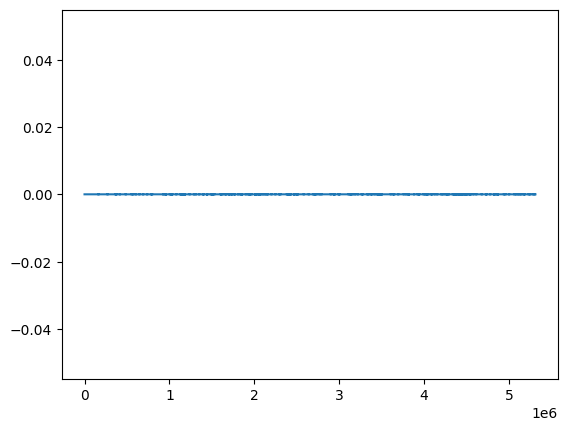

In [9]:
GASTOHOGAR_luz['prueba'].plot()

In [10]:
viv_tiradas_periodo_fact = GASTOHOGAR_luz_original['factor'].sum() - GASTOHOGAR_luz['factor'].sum()
porcent_tiradas_periodo_fact = viv_tiradas_periodo_fact/ GASTOHOGAR_luz_original['factor'].sum() *100
print(viv_tiradas_periodo_fact, porcent_tiradas_periodo_fact)

919943 2.6025257096671575


In [11]:
GASTOHOGAR_luz_edo = GASTOHOGAR_luz.loc[GASTOHOGAR_luz['entidad'] == 4].copy()
GASTOHOGAR_luz_edo

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor,prueba
519203,401161020,1,045100,250.0,2.0,2409,375.0,4,141,0.0
519244,401161021,1,045100,388.0,2.0,2409,582.0,4,141,0.0
519275,401161022,1,045100,485.0,2.0,2409,727.5,4,141,0.0
519332,401161024,1,045100,300.0,2.0,2409,450.0,4,141,0.0
519419,401161301,1,045100,258.0,2.0,2407,387.0,4,141,0.0
...,...,...,...,...,...,...,...,...,...,...
649678,461430717,1,045100,550.0,2.0,2410,825.0,4,124,0.0
649838,461430920,1,045100,20.0,1.0,2410,60.0,4,124,0.0
649932,461430922,1,045100,20.0,1.0,2410,60.0,4,124,0.0
649977,461430923,1,045100,25.0,1.0,2410,75.0,4,124,0.0


In [12]:
GASTOHOGAR_luz_edo['ultim_pago'].value_counts()

ultim_pago
2409    659
2408    486
2410    421
2407    336
2406     58
2411     29
2404      6
2405      6
2401      2
2402      2
2308      1
2307      1
0010      1
2312      1
Name: count, dtype: int64

In [13]:
# Convertir a string y tomar los últimos 2 dígitos
GASTOHOGAR_luz_edo["mes_cobro"] = (
    GASTOHOGAR_luz_edo["ultim_pago"]
    .astype(str)
    .str[-2:]          # últimos dos dígitos
    # .map(mapa_meses)   # asignar nombre del mes
)
GASTOHOGAR_luz_edo["dia_cobro"] = (
    GASTOHOGAR_luz_edo["ultim_pago"]
    .astype(str)
    .str[0:2]
    # .int()# primeros dos dígitos
)
GASTOHOGAR_luz_edo['dia_cobro'] = pd.to_numeric(GASTOHOGAR_luz_edo['dia_cobro'], errors='coerce')
GASTOHOGAR_luz_edo['mes_cobro'] = pd.to_numeric(GASTOHOGAR_luz_edo['mes_cobro'], errors='coerce')

GASTOHOGAR_luz_edo

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor,prueba,mes_cobro,dia_cobro
519203,401161020,1,045100,250.0,2.0,2409,375.0,4,141,0.0,9,24
519244,401161021,1,045100,388.0,2.0,2409,582.0,4,141,0.0,9,24
519275,401161022,1,045100,485.0,2.0,2409,727.5,4,141,0.0,9,24
519332,401161024,1,045100,300.0,2.0,2409,450.0,4,141,0.0,9,24
519419,401161301,1,045100,258.0,2.0,2407,387.0,4,141,0.0,7,24
...,...,...,...,...,...,...,...,...,...,...,...,...
649678,461430717,1,045100,550.0,2.0,2410,825.0,4,124,0.0,10,24
649838,461430920,1,045100,20.0,1.0,2410,60.0,4,124,0.0,10,24
649932,461430922,1,045100,20.0,1.0,2410,60.0,4,124,0.0,10,24
649977,461430923,1,045100,25.0,1.0,2410,75.0,4,124,0.0,10,24


In [14]:
GASTOHOGAR_luz_edo.dtypes

folioviv        int64
foliohog        int64
clave          object
gasto         float64
num_meses     float64
ultim_pago     object
gasto_tri     float64
entidad         int64
factor          int64
prueba        float64
mes_cobro       int64
dia_cobro       int64
dtype: object

In [15]:
GASTOHOGAR_luz_edo['dia_cobro'].value_counts()

dia_cobro
24    2005
23       3
0        1
Name: count, dtype: int64

In [16]:
# Se considera la fecha de pago como si todos los usuarios hubieran pagado el ultimo dia, por lo tanto, el recibo tuvo que haberse emitido 
# 10 dias antes, "El suministrador deberá conceder al usuario un plazo de diez días naturales a partir de la fecha de entrega del aviso-recibo 
# por parte del mismo suministrador, para cubrir el monto del adeudo https://www.cfe.gob.mx/finanzas/financiamiento/Documents/Emisiones%20Nacionales/CFE--Programa%20%20CBs%202016--Prospecto%20Colocaci%C3%B3n%20Definitivo.pdf?csf=1&e=4Vcf0I&utm_source=chatgpt.com

# Asimismo, en el caso de los servicios con Facturación bimestral, el "USUARIO DE SUMINISTRO BÁSICO" acepta que las Cuotas 
# aplicables para todo el consumo serán las vigentes treinta días naturales antes de la fecha de término del periodo que abarca
# dicha Facturación. https://dof.gob.mx/nota_detalle_popup.php?codigo=5628991

# Estas dos implicaciones se consideran de la siguiente manera, si el dia de pago es durante los primeros 10 dias del mes, quiere decir que el recibo
# se emitio al final del mes anterior, y como indica la segunda cita, el precio que toman en cuenta es 30 dias antes de que termine el periodo de facturacion
# por ello se le resta un mes mas, 2 en total 
# Para los casos en los que el recibo se emitio el mismo dia del pago, solo se resta un mes (por los 30 dias que se tienen que retroceder segun la 
# segunda cita) 

def calcular_mes_tarifa(df):
    def regla(dia, mes):
        # Si falta algún dato → NaN
        if pd.isna(dia) or pd.isna(mes):
            return np.nan
        
        # Aplicar reglas
        if dia <= 10:
            return mes - 2
        elif 10 < dia <= 31:
            return mes - 1
        else:
            return np.nan  # Día inválido

    df['mes_tarifa'] = df.apply(lambda row: regla(row['dia_cobro'], row['mes_cobro']), axis=1)
    return df

In [17]:
GASTOHOGAR_luz_edo = calcular_mes_tarifa(GASTOHOGAR_luz_edo)
GASTOHOGAR_luz_edo

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor,prueba,mes_cobro,dia_cobro,mes_tarifa
519203,401161020,1,045100,250.0,2.0,2409,375.0,4,141,0.0,9,24,8
519244,401161021,1,045100,388.0,2.0,2409,582.0,4,141,0.0,9,24,8
519275,401161022,1,045100,485.0,2.0,2409,727.5,4,141,0.0,9,24,8
519332,401161024,1,045100,300.0,2.0,2409,450.0,4,141,0.0,9,24,8
519419,401161301,1,045100,258.0,2.0,2407,387.0,4,141,0.0,7,24,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
649678,461430717,1,045100,550.0,2.0,2410,825.0,4,124,0.0,10,24,9
649838,461430920,1,045100,20.0,1.0,2410,60.0,4,124,0.0,10,24,9
649932,461430922,1,045100,20.0,1.0,2410,60.0,4,124,0.0,10,24,9
649977,461430923,1,045100,25.0,1.0,2410,75.0,4,124,0.0,10,24,9


In [18]:
mapa_meses = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre"
}

GASTOHOGAR_luz_edo['mes_tarifa_nombre'] = (
    GASTOHOGAR_luz_edo['mes_tarifa']
    .map(mapa_meses)
)

GASTOHOGAR_luz_edo

,folioviv,foliohog,clave,gasto,num_meses,ultim_pago,gasto_tri,entidad,factor,prueba,mes_cobro,dia_cobro,mes_tarifa,mes_tarifa_nombre
519203,401161020,1,045100,250.0,2.0,2409,375.0,4,141,0.0,9,24,8,agosto
519244,401161021,1,045100,388.0,2.0,2409,582.0,4,141,0.0,9,24,8,agosto
519275,401161022,1,045100,485.0,2.0,2409,727.5,4,141,0.0,9,24,8,agosto
519332,401161024,1,045100,300.0,2.0,2409,450.0,4,141,0.0,9,24,8,agosto
519419,401161301,1,045100,258.0,2.0,2407,387.0,4,141,0.0,7,24,6,junio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649678,461430717,1,045100,550.0,2.0,2410,825.0,4,124,0.0,10,24,9,septiembre
649838,461430920,1,045100,20.0,1.0,2410,60.0,4,124,0.0,10,24,9,septiembre
649932,461430922,1,045100,20.0,1.0,2410,60.0,4,124,0.0,10,24,9,septiembre
649977,461430923,1,045100,25.0,1.0,2410,75.0,4,124,0.0,10,24,9,septiembre


In [19]:
GASTOHOGAR_luz_edo['mes_tarifa_nombre'].value_counts()

mes_tarifa_nombre
agosto        660
julio         487
septiembre    421
junio         337
mayo           58
octubre        29
marzo           6
abril           6
enero           2
noviembre       1
Name: count, dtype: int64

In [20]:
verano = ["abril","mayo","junio","julio","agosto","septiembre"]
no_verano = ["enero","febrero","marzo", "octubre", "noviembre", "diciembre"]

df_no_verano = GASTOHOGAR_luz_edo.loc[GASTOHOGAR_luz_edo['mes_tarifa_nombre'].isin(no_verano)]
df_verano = GASTOHOGAR_luz_edo.loc[GASTOHOGAR_luz_edo['mes_tarifa_nombre'].isin(verano)]

viv_verano = df_verano['factor'].sum()

# tabla = pd.DataFrame({
#     "Bloque": ["basico", "intermedios", "DAC", "sin_bloque"],
#     "Viviendas": [bases, intermedios, DACs, bloque_nan],
# })

# tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# # Formato con separador de miles
# tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")
# tabla

# Mejor hay que pasarlo con el 005 para ya considerar todo en uno mismo